## Why Data Augmentation Is Required

**Data Augmentation** means creating slightly modified versions of existing images to increase the variety of training data.

For example, if we have one image of a cat, we can create new training images by:
- Flipping it horizontally
- Rotating it
- Cropping it
- Changing its brightness
- Translating it slightly

The original image is not changed permanently. Instead, modified versions are used during training.

### Why do we need augmentation?

A CNN can sometimes **memorize the training images** instead of learning general features. This can cause **overfitting**.

Data augmentation provides different versions of the same image, so the model learns features that are more robust to changes in position, orientation, lighting, and size.

### Without Augmentation

The model may see:

`Cat → same position → same lighting → same size`

The model can become too dependent on the training images.

### With Augmentation

The model may see:

`Cat → flipped`  
`Cat → rotated`  
`Cat → cropped`  
`Cat → shifted`  
`Cat → brighter/darker`

This helps the model learn:

**"What makes this a cat?"**

instead of:

**"What does this exact training image look like?"**

### Main benefits

- Helps reduce overfitting
- Improves generalization
- Makes the model more robust
- Creates more variety from existing images
- Useful when the available dataset is small

### Real-World Example

Suppose a face-recognition dataset contains a person's face mostly in normal lighting.

In real life, the same person may appear:
- Slightly rotated
- In a different position
- In brighter or darker lighting

Augmentation can expose the model to these variations during training.

**Key point:** Data augmentation helps a CNN learn useful image features rather than memorizing the exact training images.

## Horizontal Flip

A **horizontal flip** mirrors an image from left to right.

For example:

**Original:**  
👤 → face looking normally

**Horizontal Flip:**  
👤 → left and right sides are swapped

The image is flipped along the **vertical axis**.

### Why do we need it?

It helps the CNN learn that an object can appear in either left or right orientation.

For example, if a training image contains a car facing left, horizontal flipping creates a similar image of the car facing right.

### Real-World Example

For **car image classification**, a car may appear facing either left or right.

Horizontal flipping gives the model both variations, helping it recognize the car regardless of its direction.

**Key point:** Horizontal flip swaps the left and right sides of an image and can improve model generalization when left/right orientation does not change the image's class.

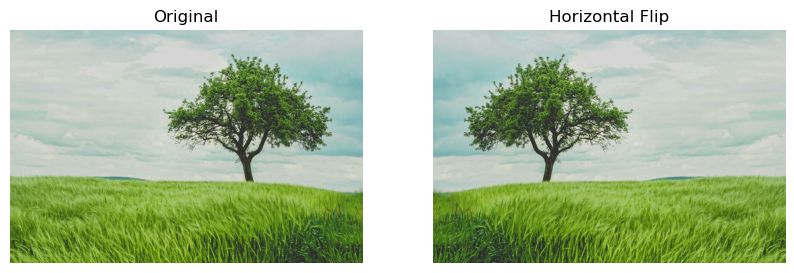

In [4]:
### Python Example

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg")

# Horizontal flip
flipped_image = image.transpose(Image.FLIP_LEFT_RIGHT)

# Display original and flipped image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flipped_image)
plt.title("Horizontal Flip")
plt.axis("off")

plt.show()


## Vertical Flip

A **vertical flip** turns an image upside down.

It flips the image along the **horizontal axis**.

For example:

**Original**

⬆️  
Image

**Vertical Flip**

Image  
⬇️

### Why do we need it?

Vertical flipping can help the model learn different orientations of an object.

However, it should be used **only when an upside-down image still makes sense for the problem**.

For example:
- Some natural images → may be suitable
- General objects → sometimes suitable
- Text or human faces → usually not suitable

### Real-World Example

Suppose we are classifying objects where their orientation can vary.

A vertical flip can create an additional training example with the object in an upside-down orientation.

**Key point:** Vertical flip changes the top and bottom of an image. Use it only when this transformation is realistic for the dataset.

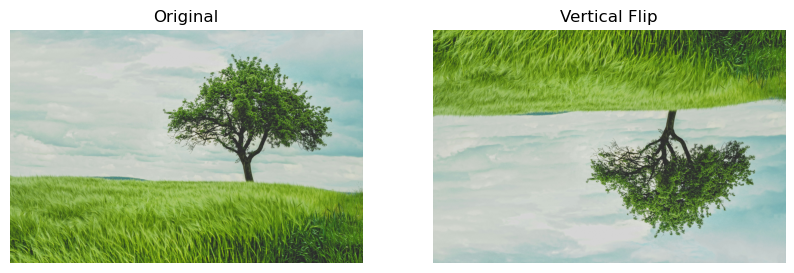

In [5]:

### Python Example

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Vertical flip
flipped_image = image.transpose(Image.FLIP_TOP_BOTTOM)

# Display original and flipped image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flipped_image)
plt.title("Vertical Flip")
plt.axis("off")

plt.show()



## Rotation

**Rotation** means turning an image by a certain angle.

For example, an image can be rotated by:
- 10°
- 20°
- 30°
- 90°

During augmentation, we normally use **small random rotations** so the image still looks realistic.

### Why do we need it?

In real-world images, objects may not always be perfectly straight.

Rotation helps the CNN recognize an object even when it is slightly tilted.

``

### Real-World Example

Suppose we are training a model to identify **cars**.

A car in a real photograph may be slightly tilted because of the camera angle.

Rotation augmentation helps the model recognize the car even when it is not perfectly aligned.

**Key point:** Rotation creates different orientations of the same image and can improve the model's generalization.

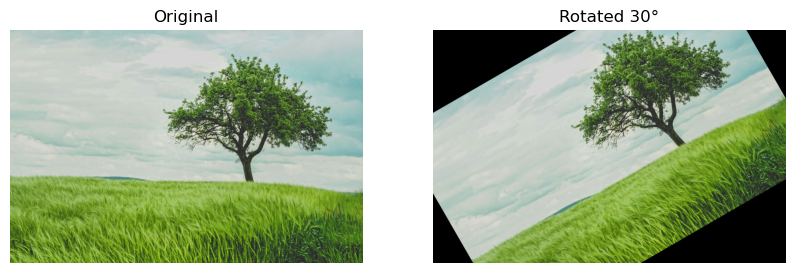

In [6]:
### Python Example

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Rotate image by 30 degrees
rotated_image = image.rotate(30)

# Display original and rotated image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated_image)
plt.title("Rotated 30°")
plt.axis("off")

plt.show()


## Random Crop

**Random Crop** means selecting a random smaller part of an image and using that part as the training image.

For example, instead of using the complete image, we may randomly select an area containing the important object.

### Why do we need it?

In real-world images, the object may appear:
- At different positions
- Partially visible
- Closer to or farther from the camera

Random cropping helps the model learn the important features of an object instead of depending on its exact position in the image.
`

### Real-World Example

Suppose we are training a model to recognize **dogs**.

The dog may appear in different locations in photographs. Random cropping can show the model different parts and positions of the dog.

This helps the model focus on the dog's useful features rather than its exact location.

**Key point:** Random crop changes which part of the image the model sees and helps it become less dependent on the object's exact position.

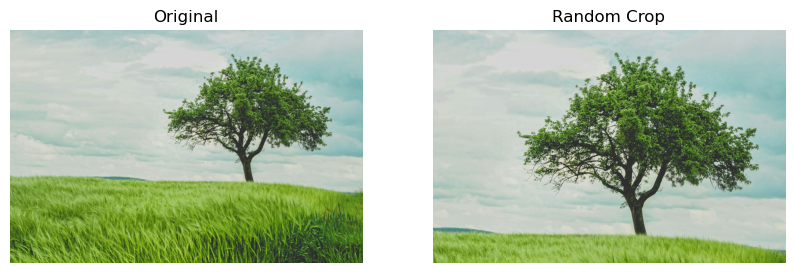

In [8]:

### Python Example

from PIL import Image
import matplotlib.pyplot as plt
import random

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Get image size
width, height = image.size

# Crop size
crop_width = int(width * 0.7)
crop_height = int(height * 0.7)

# Random starting position
left = random.randint(0, width - crop_width)
top = random.randint(0, height - crop_height)

# Perform random crop
cropped_image = image.crop(
    (left, top, left + crop_width, top + crop_height)
)

# Display original and cropped image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title("Random Crop")
plt.axis("off")

plt.show()


## Resize

**Resize** means changing the width and height of an image.

For example:

`Original → 800 × 600`

`Resized → 224 × 224`

CNN models usually require images to have a fixed size, so resizing is commonly used during image preprocessing.

### Why do we need it?

Resize helps to:

- Make all images the same size
- Provide a consistent input size to the CNN
- Reduce image size and computational requirements

### Real-World Example

Suppose our dataset contains images with different sizes:

- Image 1 → 800 × 600
- Image 2 → 1024 × 768
- Image 3 → 500 × 500

Before giving them to a CNN, we can resize them to:

**224 × 224**

Now all images have the same input dimensions.

**Key point:** Resize makes images a consistent size so they can be used as CNN input.

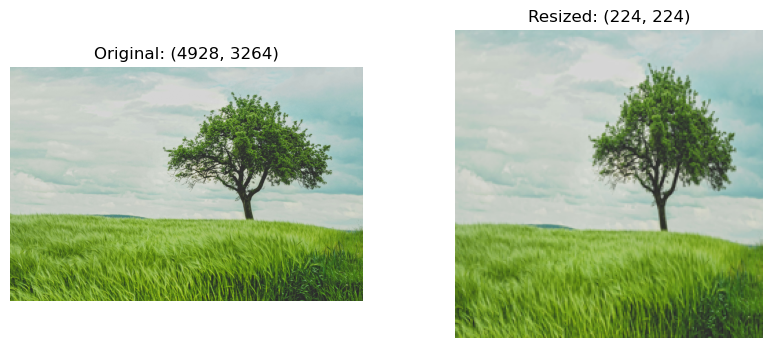

In [9]:

### Python Example
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Resize image
resized_image = image.resize((224, 224))

# Display original and resized image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title(f"Resized: {resized_image.size}")
plt.axis("off")

plt.show()



## Translation

**Translation** means moving an image slightly **left, right, up, or down** without changing its size or orientation.

For example:

- Move right → image shifts to the right
- Move left → image shifts to the left
- Move up → image shifts upward
- Move down → image shifts downward

### Why do we need it?

In real-world images, an object may not always appear in the center.

Translation helps the CNN learn that the object is still the same even when its position changes.

### Real-World Example

Suppose a camera captures a **car**.

In one image, the car may be in the center. In another image, the car may be slightly toward the left or right.

Translation augmentation helps the model recognize the car regardless of its position.

**Key point:** Translation changes the **position** of the image while keeping its orientation and size the same.

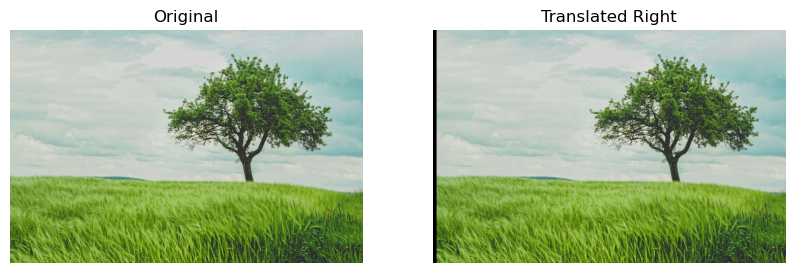

In [11]:

### Python Example
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Move image 50 pixels to the right
translated_image = image.transform(
    image.size,
    Image.AFFINE,
    (1, 0, -50, 0, 1, 0)
)

# Display original and translated image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated_image)
plt.title("Translated Right")
plt.axis("off")

plt.show()



## Brightness / Contrast Changes

**Brightness** controls how light or dark an image appears.

**Contrast** controls the difference between bright and dark areas of an image.

During augmentation, we can randomly change brightness and contrast to create different versions of the same image.

### Why do we need it?

Real-world images can have different lighting conditions.

For example:
- Bright sunlight
- Low light
- Indoor lighting
- Shadows
- Different camera exposure

Brightness and contrast augmentation helps the CNN recognize objects under these different conditions.

### Real-World Example

Suppose a model is trained to identify **road signs**.

The same sign may be captured:
- During bright sunlight
- During cloudy weather
- In low light

Brightness and contrast augmentation helps the model handle these lighting differences.

**Key point:** Brightness and contrast augmentation helps the model become more robust to different lighting conditions.

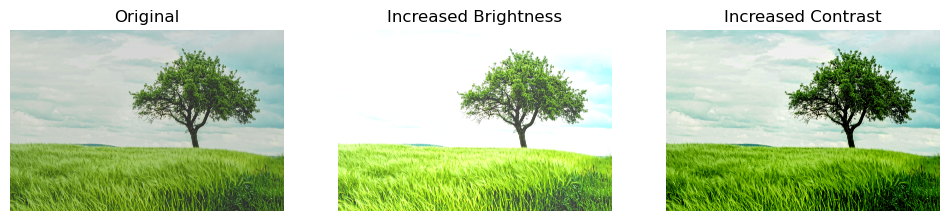

In [12]:

### Python Example

from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Change brightness
bright_image = ImageEnhance.Brightness(image).enhance(1.5)

# Change contrast
contrast_image = ImageEnhance.Contrast(image).enhance(1.5)

# Display images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bright_image)
plt.title("Increased Brightness")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contrast_image)
plt.title("Increased Contrast")
plt.axis("off")

plt.show()



## Random Affine Transformation

A **Random Affine Transformation** applies one or more geometric changes to an image.

It can combine transformations such as:

- Rotation
- Translation
- Scaling
- Shearing

Instead of applying the same transformation every time, the values can be **randomly selected**.

### Why do we need it?

In real-world images, objects can appear:

- Slightly rotated
- Shifted from their original position
- Larger or smaller
- Slightly tilted

Random affine transformation helps the CNN learn from these variations and improves **generalization**.


### What is happening?

```text
degrees=20
```
Allows random rotation up to 20°.

```text
translate=(0.1, 0.1)
```
Allows the image to move horizontally and vertically.

```text
scale=(0.8, 1.2)
```
Allows the image to become slightly smaller or larger.

```text
shear=10
```
Allows the image to become slightly tilted.

### Real-World Example

Suppose we are training a model to recognize **cars**.

A real photograph may contain a car that is:
- Slightly rotated
- Positioned toward one side
- Closer to the camera
- Viewed at a slight angle

Random affine transformation creates similar variations during training.

**Key point:** Random affine transformation combines geometric changes such as rotation, translation, scaling, and shearing to make training images more varied.

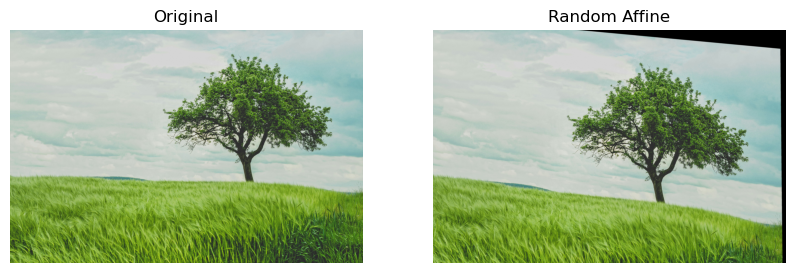

In [13]:

### Python Example

from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Random affine transformation
affine = transforms.RandomAffine(
    degrees=20,
    translate=(0.1, 0.1),
    scale=(0.8, 1.2),
    shear=10
)

affine_image = affine(image)

# Display original and transformed image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(affine_image)
plt.title("Random Affine")
plt.axis("off")

plt.show()


## Without Augmentation vs With Augmentation

We can compare a CNN trained in two ways:

1. **Without Data Augmentation**
2. **With Data Augmentation**

The main purpose is to understand how augmentation affects **training accuracy, validation accuracy, overfitting, and generalization**.

### 1. Training Accuracy

**Without augmentation:**

The model may achieve very high training accuracy because it sees the original images repeatedly.

**With augmentation:**

Training accuracy may be slightly lower because the model is trained on more varied and difficult versions of the images.

### 2. Validation Accuracy

**Without augmentation:**

Validation accuracy may be lower if the model has memorized the training images.

**With augmentation:**

Validation accuracy can improve because the model learns more general features.

### 3. Overfitting

**Without augmentation:**

There is a higher chance of overfitting, especially when the dataset is small.

**With augmentation:**

Augmentation can reduce overfitting by providing different versions of training images.

### 4. Generalization

**Without augmentation:**

The model may perform well on images similar to the training data but struggle with new variations.

**With augmentation:**

The model can become more robust to changes such as position, rotation, lighting, and scale.

### Simple Comparison

| Factor | Without Augmentation | With Augmentation |
|---|---|---|
| Training Accuracy | Often higher | May be slightly lower |
| Validation Accuracy | May be lower | Often improves |
| Overfitting | Higher risk | Lower risk |
| Generalization | Weaker | Better |
| Training Data Variety | Low | Higher |

### Important Point

Higher training accuracy does **not always mean a better model**.

For example:

```text
Without Augmentation
Training Accuracy   → 98%
Validation Accuracy → 75%

With Augmentation
Training Accuracy   → 92%
Validation Accuracy → 87%
```

The augmented model has lower training accuracy but better validation accuracy.

This suggests that it is **generalizing better** and is less likely to be overfitting.

### Final Understanding

```text
Without Augmentation
        ↓
Model sees limited image variations
        ↓
Higher risk of memorization
        ↓
Overfitting
        ↓
Poorer generalization


With Augmentation
        ↓
Model sees varied image versions
        ↓
Learns more robust features
        ↓
Less overfitting
        ↓
Better generalization
```

**Key point:** Data augmentation is mainly used to improve **generalization** and reduce **overfitting**. Training accuracy may decrease slightly, but validation performance can improve.